In [ ]:
# %%
# 일반 통화 데이터셋 전처리 및 분석
# 프로젝트: 보이스 피싱 근절 시스템
# 목표: 일반 통화 데이터를 전처리하여 보이스 피싱 판별 모델 학습을 위한 데이터셋 구성

# 작업 목적:
# 1. 일반 통화 텍스트 데이터를 분석하고 전처리
# 2. 보이스 피싱 데이터와 결합할 수 있는 형태로 데이터셋 구성
# 3. ML/DL 모델 학습에 적합한 형태로 데이터 가공
# 4. 감정 분류, 화자 분리, 텍스트 특성 분석을 통한 데이터 품질 확보

# 데이터 흐름:
# 일반 통화 데이터 → 전처리 → 보이스 피싱 데이터와 결합 → ML/DL 모델 학습 → 보이스 피싱 판별 시스템

print("보이스 피싱 근절 시스템 - 일반 통화 데이터 전처리 시작")

# %%
# 필요한 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
import re
from collections import Counter
import json
# import matplotlib
import platform
from matplotlib import font_manager, rc

warnings.filterwarnings("ignore")

%matplotlib inline

# 마이너스 부호가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

# 운영체제에 맞는 한글 폰트 설정
if platform.system() == 'Windows':
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc('font', family=font_name)
elif platform.system() == 'Darwin': # Mac OS
    rc('font', family='AppleGothic')
else: # Linux
    # Linux 시스템에서는 'NanumGothic' 같은 폰트를 미리 설치해야 할 수 있습니다.
    # 예: sudo apt-get install fonts-nanum*
    rc('font', family='NanumGothic')

# Seaborn 스타일 설정
sns.set(style="whitegrid")

# 📌 Jupyter에서 한글 깨짐 방지 + 스타일 설정
# %matplotlib inline
# import platform
# from matplotlib import font_manager, rc

# plt.rcParams['axes.unicode_minus'] = False
# if platform.system() == 'Windows':
#     font_path = "C:/Windows/Fonts/malgun.ttf"
#     font_name = font_manager.FontProperties(fname=font_path).get_name()
#     rc('font', family=font_name)
# else:
#     rc('font', family='AppleGothic')

# sns.set(style="whitegrid")


# # 한글 폰트 설정 (운영체제별)
# if platform.system() == "Windows":
#     matplotlib.rc("font", family="Malgun Gothic")
# elif platform.system() == "Darwin":
#     matplotlib.rc("font", family="AppleGothic")
# else:
#     matplotlib.rc("font", family="DejaVu Sans")

# plt.rcParams["axes.unicode_minus"] = False

# # 시각화 스타일 설정
# plt.style.use("seaborn-v0_8")
# sns.set_palette("husl")

# print("라이브러리 import 완료")

보이스 피싱 근절 시스템 - 일반 통화 데이터 전처리 시작


In [10]:
# %%
# 1. 데이터셋 파일 확인 및 로드
# dataset 폴더 경로 설정
dataset_path = Path("../../dataset")

# CSV 파일 목록 확인
csv_files = list(dataset_path.glob("normal_dataset*.csv"))
print(f"발견된 CSV 파일 수: {len(csv_files)}")
for file in csv_files:
    print(f"- {file.name}")

# 파일 크기 확인
for file in csv_files:
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f"  {file.name}: {size_mb:.2f} MB")

발견된 CSV 파일 수: 3
- normal_dataset(콜센터 상담).csv
- normal_dataset2(자유대화).csv
- normal_dataset3(공감형대화).csv
  normal_dataset(콜센터 상담).csv: 555.17 MB
  normal_dataset2(자유대화).csv: 88.37 MB
  normal_dataset3(공감형대화).csv: 50.44 MB


In [11]:
# %%
# 각 CSV 파일을 딕셔너리에 저장
dataframes = {}

for file in csv_files:
    try:
        # UTF-8 인코딩으로 파일 로드
        df = pd.read_csv(file, encoding="utf-8-sig")
        dataframes[file.stem] = df

        print(f"\n=== {file.name} 기본 정보 ===")
        print(f"Shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        print(f"\n첫 5행:")
        print(df.head())
        print(f"\n데이터 타입:")
        print(df.dtypes)
        print(f"\n결측값:")
        print(df.isnull().sum())

        # 메모리 사용량 확인
        memory_usage = df.memory_usage(deep=True).sum() / 1024**2
        print(f"메모리 사용량: {memory_usage:.2f} MB")

    except Exception as e:
        print(f"Error loading {file.name}: {e}")


=== normal_dataset(콜센터 상담).csv 기본 정보 ===
Shape: (4426586, 5)
Columns: ['file_name', 'category', 'subcategory', 'spk', 'msg']

첫 5행:
      file_name category subcategory  spk  \
0  S000001.json       교육        공부방법    1   
1  S000001.json       교육        기타문의    1   
2  S000001.json       교육        기타문의    1   
3  S000001.json       교육        기타문의    2   
4  S000001.json       교육        기타문의    1   

                                               msg  
0                      그 저기 뭐지 예 수학 선생님들이 여러분 계신데.  
1  n/ 네 그래요 그러면 얘한테 뭐 듣고 (싶) 우선은 (연) 연장 (가) 근데 여기가  
2                    조금 이런 게 안 좋은 것 (같아요)/(같애요)l/.  
3                        n/ 그 부분은 꼭 건의드리겠습니다. 어머니.  
4              n/ 네 좀 이런 부분은 조금 불편한 것 같네요 그러고 보니까.  

데이터 타입:
file_name      object
category       object
subcategory    object
spk             int64
msg            object
dtype: object

결측값:
file_name      0
category       0
subcategory    0
spk            0
msg            0
dtype: int64
메모리 사용량: 1753.89 MB

=== normal_dataset2(

In [12]:
# ==============================================================================
# 2. 데이터 구조 분석 및 보이스 피싱 데이터와의 호환성 검토 (수정 적용된 코드)
# ==============================================================================
print("\n" + "=" * 60)
print("  데이터 구조 심층 분석 및 집계 시작")
print("=" * 60 + "\n")

# dataframes 딕셔너리에 저장된 각 데이터프레임에 대해 분석 수행
for name, df in dataframes.items():
    print(f" {name} 데이터셋")

    # 'file_name'과 'msg' 컬럼이 있는지 확인하여 오류 방지
    if "file_name" in df.columns and "msg" in df.columns:

        # 1. file_name 기준으로 그룹화 및 msg 텍스트 병합
        print("    'file_name' 기준으로 데이터 집계 중...")
        agg_df = df.groupby("file_name", as_index=False).agg(
            {"msg": " ".join, "category": "first", "subcategory": "first"}
        )
        print(f"     집계 완료! 총 {len(agg_df)}개의 고유한 파일로 재구성되었습니다.\n")

        analysis_df = agg_df

    else:
        print("    'file_name' 또는 'msg' 컬럼이 없어 집계를 건너뜁니다.\n")
        analysis_df = df

    # 2. 집계된 데이터프레임(analysis_df)을 기준으로 구조 분석
    print(f"      집계 후 데이터 구조 분석:")
    print(f"      컬럼 구조:")
    for col in analysis_df.columns:
        print(f"      - {col}:")
        print(f"        타입: {analysis_df[col].dtype}")

        if col == "file_name":
            print(f"        고유값 수: {len(analysis_df)}")
        else:
            print(f"        고유값 수: {analysis_df[col].nunique()}")

        if analysis_df[col].dtype == "object":
            non_null = analysis_df[col].dropna()
            if len(non_null) > 0:
                avg_length = non_null.astype(str).str.len().mean()
                print(f"        평균 길이: {avg_length:.1f} 문자")
                print(f"        샘플 값: {non_null.iloc[0][:100]}...")
        print()

    # 3. 보이스 피싱 데이터와의 호환성 검토
    print(f"     보이스 피싱 데이터 호환성:")
    expected_columns = ["file_name", "category", "subcategory", "spk", "msg"]
    missing_columns = [col for col in expected_columns if col not in df.columns]

    if missing_columns:
        print(f"        누락된 컬럼: {missing_columns}")
    else:
        print(f"        모든 필수 컬럼 존재")

    print("\n" + "=" * 50 + "\n")


  데이터 구조 심층 분석 및 집계 시작

 normal_dataset(콜센터 상담) 데이터셋
    'file_name' 기준으로 데이터 집계 중...
     집계 완료! 총 38329개의 고유한 파일로 재구성되었습니다.

      집계 후 데이터 구조 분석:
      컬럼 구조:
      - file_name:
        타입: object
        고유값 수: 38329
        평균 길이: 12.0 문자
        샘플 값: S000001.json...

      - msg:
        타입: object
        고유값 수: 38329
        평균 길이: 4488.1 문자
        샘플 값: 그 저기 뭐지 예 수학 선생님들이 여러분 계신데. n/ 네 그래요 그러면 얘한테 뭐 듣고 (싶) 우선은 (연) 연장 (가) 근데 여기가 조금 이런 게 안 좋은 것 (같아요)/(같애...

      - category:
        타입: object
        고유값 수: 4
        평균 길이: 4.1 문자
        샘플 값: 교육...

      - subcategory:
        타입: object
        고유값 수: 20
        평균 길이: 9.4 문자
        샘플 값: 공부방법...

     보이스 피싱 데이터 호환성:
        모든 필수 컬럼 존재


 normal_dataset2(자유대화) 데이터셋
    'file_name' 기준으로 데이터 집계 중...
     집계 완료! 총 25456개의 고유한 파일로 재구성되었습니다.

      집계 후 데이터 구조 분석:
      컬럼 구조:
      - file_name:
        타입: object
        고유값 수: 25456
        평균 길이: 23.4 문자
        샘플 값: Empathy_기쁨_부모자녀_조손_1.json...

      - msg:
        

In [6]:
# 집계된 데이터프레임을 저장할 딕셔너리
aggregated_dataframes = {}

for name, df in dataframes.items():
    print(f"  {name} 데이터셋 집계 중...")
    if "file_name" in df.columns and "msg" in df.columns:
        agg_df = df.groupby("file_name", as_index=False).agg(
            {"msg": " ".join, "category": "first", "subcategory": "first"}
        )
        # 텍스트 길이 피처 추가
        agg_df["text_length"] = agg_df["msg"].str.len()
        aggregated_dataframes[name] = agg_df
        print(f"     집계 완료! 총 {len(agg_df)}개의 고유 파일로 재구성.")
    else:
        aggregated_dataframes[name] = df  # 집계 불가 시 원본 저장
        print(f"     '{name}' 집계 불가. 필수 컬럼을 확인하세요.")

  normal_dataset(콜센터 상담) 데이터셋 집계 중...
     집계 완료! 총 38329개의 고유 파일로 재구성.
  normal_dataset2(자유대화) 데이터셋 집계 중...
     집계 완료! 총 25456개의 고유 파일로 재구성.
  normal_dataset3(공감형대화) 데이터셋 집계 중...
     집계 완료! 총 1222개의 고유 파일로 재구성.


폰트 설정 완료: C:/Windows/Fonts/malgun.ttf


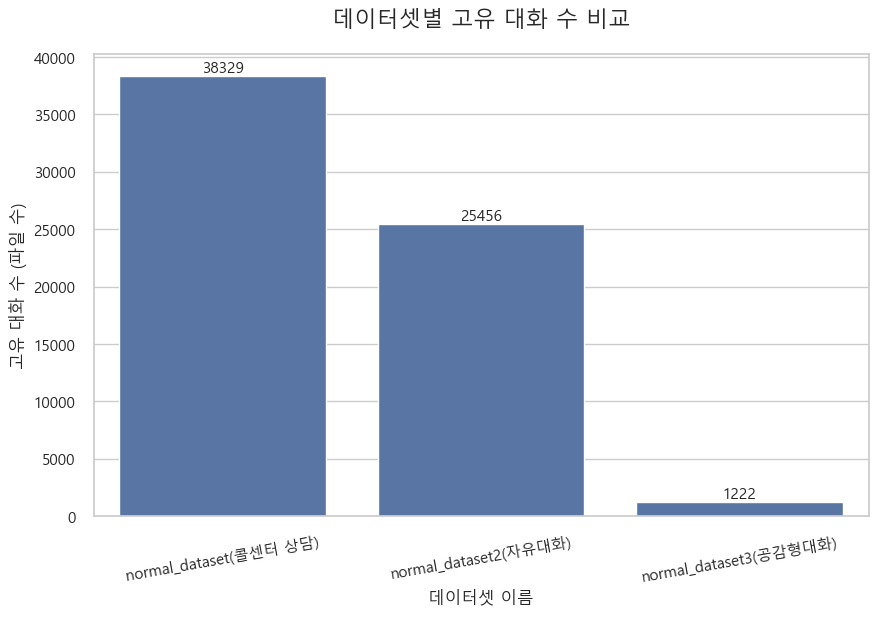

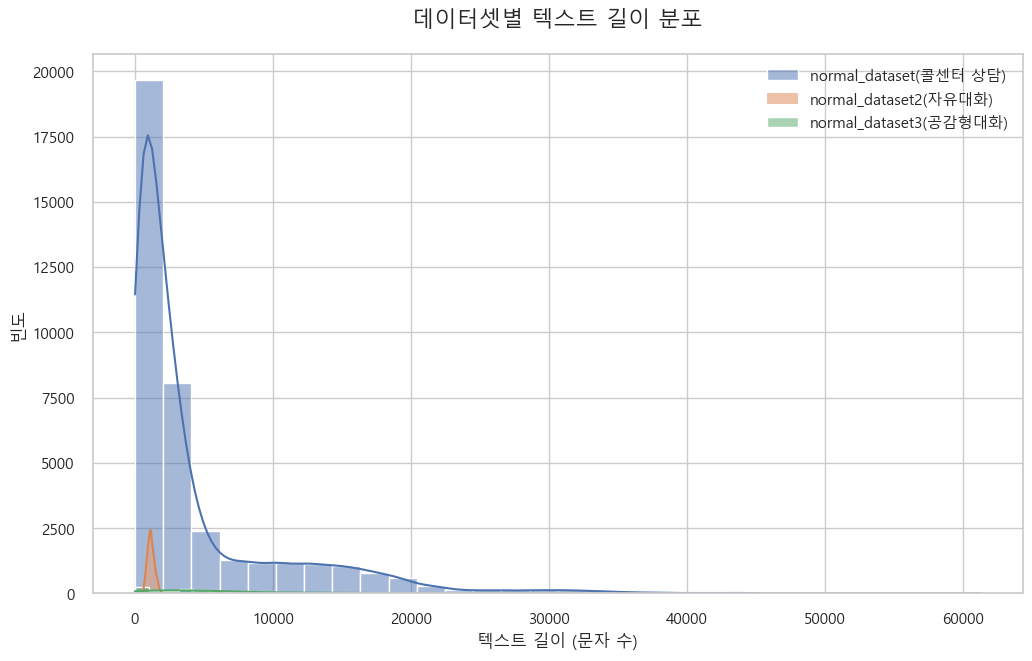

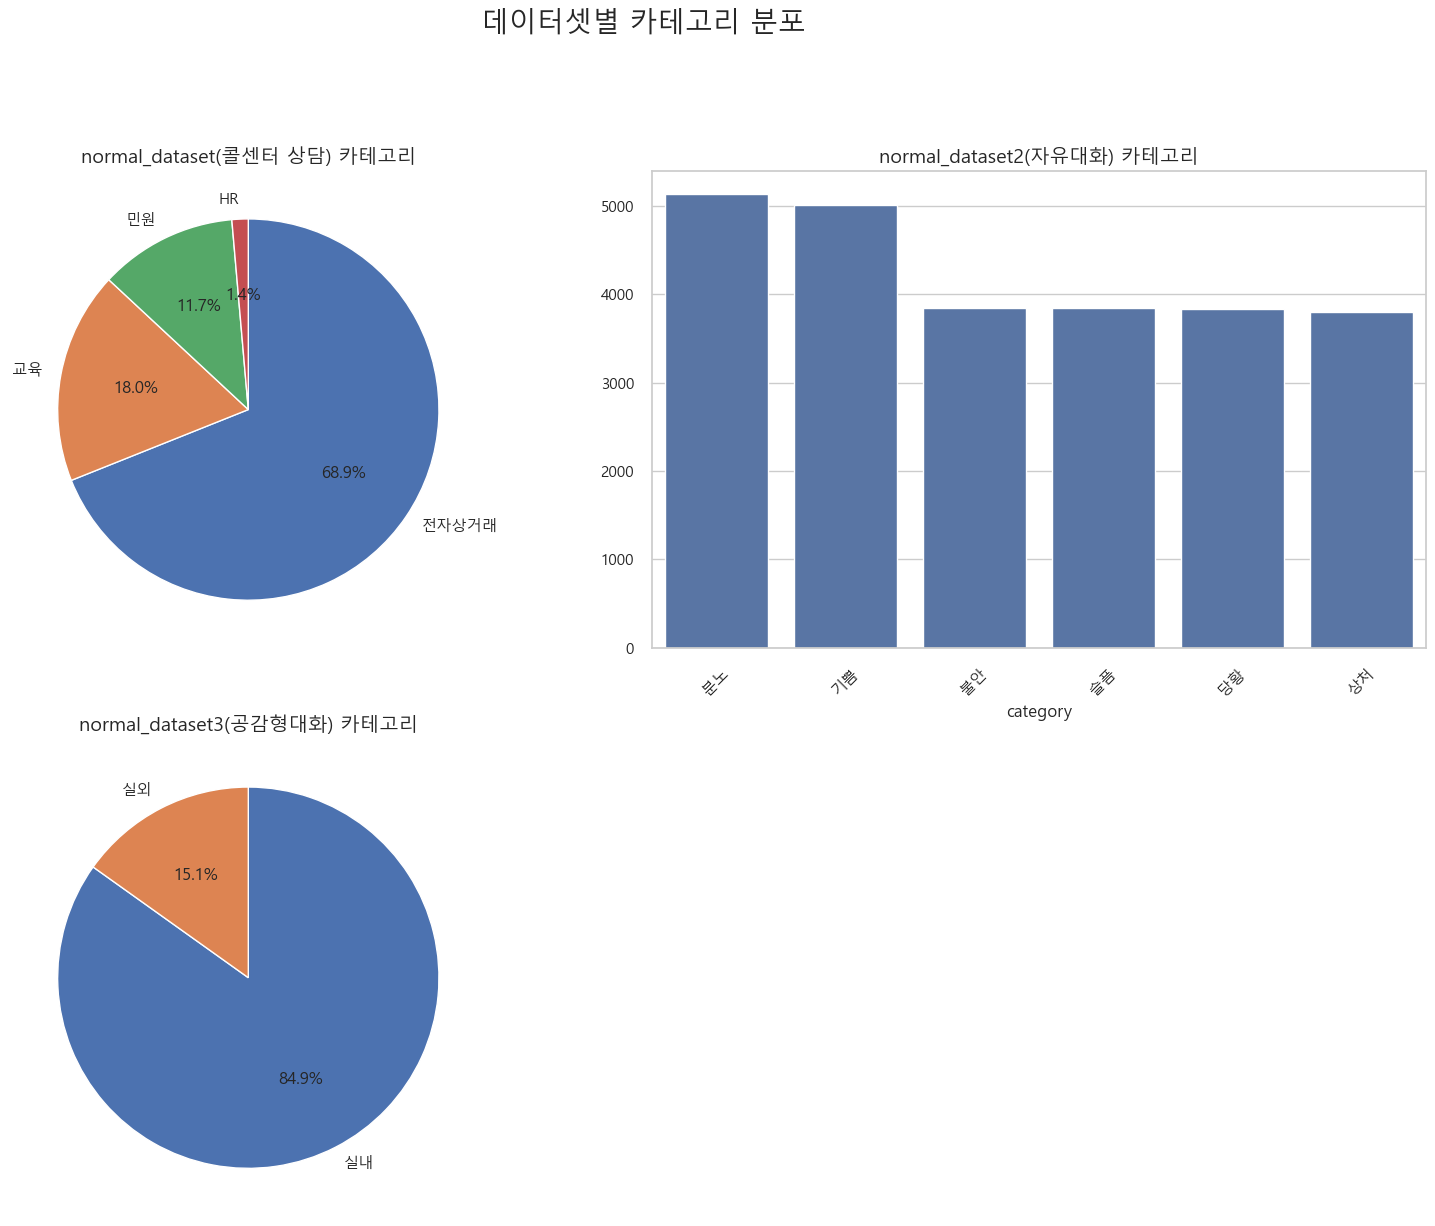


모든 시각화가 완료되었습니다.


In [22]:
# %%
# ==============================================================================
# 3. 데이터 시각화
# ==============================================================================

# 한글 폰트 설정 재적용 (시각화 전에 명시적으로 설정)
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from matplotlib import font_manager, rc

# 한글 폰트 설정
if platform.system() == 'Windows':
    # Windows 환경에서 사용 가능한 한글 폰트들
    font_candidates = [
        'C:/Windows/Fonts/malgun.ttf',
        'C:/Windows/Fonts/gulim.ttc', 
        'C:/Windows/Fonts/batang.ttc',
        'Malgun Gothic',
        'Gulim',
        'Batang'
    ]
    
    font_set = False
    for font in font_candidates:
        try:
            if font.endswith('.ttf') or font.endswith('.ttc'):
                font_name = font_manager.FontProperties(fname=font).get_name()
                rc('font', family=font_name)
            else:
                rc('font', family=font)
            font_set = True
            print(f"폰트 설정 완료: {font}")
            break
        except:
            continue
    
    if not font_set:
        print("한글 폰트 설정 실패 - 기본 폰트 사용")
        
elif platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
else:
    rc('font', family='NanumGothic')

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 3-1. 데이터셋별 크기 비교 시각화
dataset_sizes = {name: len(df) for name, df in aggregated_dataframes.items()}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(dataset_sizes.keys()), y=list(dataset_sizes.values()))
plt.title("데이터셋별 고유 대화 수 비교", fontsize=16, pad=20)
plt.xlabel("데이터셋 이름", fontsize=12)
plt.ylabel("고유 대화 수 (파일 수)", fontsize=12)
plt.xticks(rotation=10)
# 막대 위에 숫자 표시
for i, v in enumerate(list(dataset_sizes.values())):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=11)
plt.show()


# 3-2. 텍스트 길이 분포 시각화
# 여러 데이터셋의 텍스트 길이를 하나의 figure에 비교
plt.figure(figsize=(12, 7))
for name, df in aggregated_dataframes.items():
    if "text_length" in df.columns:
        sns.histplot(df["text_length"], kde=True, label=name, bins=30, alpha=0.5)

plt.title("데이터셋별 텍스트 길이 분포", fontsize=16, pad=20)
plt.xlabel("텍스트 길이 (문자 수)", fontsize=12)
plt.ylabel("빈도", fontsize=12)
plt.legend()
plt.show()


# 3-3. 카테고리 분포 시각화
# 데이터셋 개수에 따라 subplot의 레이아웃을 동적으로 결정
num_datasets = len(aggregated_dataframes)
# 2개 이하일 경우 가로로, 그 이상일 경우 2열 그리드로 배치
if num_datasets <= 2:
    fig, axes = plt.subplots(1, num_datasets, figsize=(8 * num_datasets, 6))
    if num_datasets == 1:  # 데이터셋이 하나일 경우 axes가 리스트가 아님
        axes = [axes]
else:
    nrows = (num_datasets + 1) // 2
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 6 * nrows))
    axes = axes.flatten()  # 2차원 배열을 1차원으로 변경

fig.suptitle("데이터셋별 카테고리 분포", fontsize=20, y=1.02)

for i, (name, df) in enumerate(aggregated_dataframes.items()):
    ax = axes[i]
    if "category" in df.columns:
        category_counts = df["category"].value_counts()

        # 카테고리가 5개 이하면 파이차트, 초과하면 바차트가 더 효과적
        if len(category_counts) <= 5:
            ax.pie(
                category_counts,
                labels=category_counts.index,
                autopct="%1.1f%%",
                startangle=90,
                counterclock=False,
                wedgeprops={"edgecolor": "white", "linewidth": 1},
            )
        else:
            sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
            ax.tick_params(axis="x", rotation=45)

        ax.set_title(f"{name} 카테고리", fontsize=14)
    else:
        ax.text(0.5, 0.5, "카테고리 정보 없음", ha="center", va="center")
        ax.set_title(name, fontsize=14)
        ax.axis("off")

# 남는 subplot이 있다면 비활성화
for j in range(num_datasets, len(axes)):
    axes[j].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n모든 시각화가 완료되었습니다.")